# 03 — RQ1: Electricity Mix Shift Toward Renewables

**Question:** How has Austria's electricity generation mix shifted toward renewables since 2019, and how fast?

The descriptive opener of the analysis phase. It establishes the long-run shape of the
mix that the later questions interrogate in detail — the solar duck curve (RQ3), the
merit-order effect on prices (RQ4), and the 100%-renewable-**electricity**-by-2030
trajectory (RQ5).

Primary source: **`owid_energy_at`** (Our World in Data, annual). We work in the
*electricity* column family — `*_share_elec` and per-source `*_electricity` (TWh) —
**not** the primary-energy columns (`*_share_energy`), which fold in transport and heat
and answer a different question.

| Step | What | Output |
|---|---|---|
| 1 | Coverage check — usable columns, year span, gaps, where the OWID tail cuts off | Profile tables |
| 2 | Choose the renewable-share metric + trend approach | — (decided from Step 1) |
| 3 | Headline visual + 2-sentence finding | Stacked-area mix + renewable-share trend |

**Note:** OWID is annual and its latest year typically lags — the usable window may end
before 2024. Confirmed in Step 1, not assumed.

In [1]:
# 03_rq1_energy_mix.ipynb — Cell A: connect
import duckdb
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
DB_PATH = PROJECT_ROOT / "data" / "processed" / "austria_energy.duckdb"
con = duckdb.connect(str(DB_PATH))

In [2]:
# Cell B: is the annual series contiguous?

# Summary: first/last year, row count vs the span it should cover.
display(con.sql("""
SELECT MIN(year) AS first_year,
       MAX(year) AS last_year,
       COUNT(*)  AS n_rows,
       MAX(year) - MIN(year) + 1 AS expected_rows   -- contiguous ⇒ n_rows == this
FROM owid_energy_at
""").df())

# Which years (if any) are missing inside that span?
# generate_series(lo, hi) is INCLUSIVE → a list; UNNEST expands it to rows.
# LEFT JOIN + "o.year IS NULL" = years we expected but the table doesn't have.
display(con.sql("""
WITH bounds AS (
    SELECT MIN(year) AS y0, MAX(year) AS y1 FROM owid_energy_at
),
expected AS (
    SELECT UNNEST(generate_series(y0, y1)) AS year FROM bounds
)
SELECT e.year AS missing_year
FROM expected e
LEFT JOIN owid_energy_at o USING (year)
WHERE o.year IS NULL
ORDER BY e.year
""").df())   # expect 0 rows

,first_year,last_year,n_rows,expected_rows
0,1900,2025,126,126


,missing_year


In [3]:
# Cell C: which electricity-mix columns are actually populated?

# The columns RQ1 could plausibly use. We guard against OWID vintage drift:
# if a name isn't in this file, we drop it and report it rather than erroring.
shortlist = [
    "electricity_generation", "electricity_demand",      # totals (TWh)
    "renewables_share_elec", "low_carbon_share_elec",    # shares (%)  ← headline lives here
    "fossil_share_elec",
    "renewables_electricity", "low_carbon_electricity",  # aggregates (TWh)
    "fossil_electricity",
    "hydro_electricity", "solar_electricity",            # per-source (TWh)
    "wind_electricity", "biofuel_electricity",
    "nuclear_electricity", "coal_electricity",
    "gas_electricity", "oil_electricity",
]

cols    = con.sql("DESCRIBE owid_energy_at").df()["column_name"].tolist()
present = [c for c in shortlist if c in cols]
absent  = [c for c in shortlist if c not in cols]
if absent:
    print("Not in this OWID vintage:", absent)

# SUMMARIZE profiles each column in one pass; we keep the coverage-relevant fields.
col_list = ", ".join(f'"{c}"' for c in present)
summ = con.sql(f"SUMMARIZE SELECT {col_list} FROM owid_energy_at").df()
display(summ[["column_name", "min", "max", "null_percentage", "count"]])

# The window that matters. OWID's latest year(s) lag — eyeball the tail directly
# so we know where the *usable* annual series actually ends.
display(con.sql("""
SELECT year, renewables_share_elec, electricity_generation,
       hydro_electricity, solar_electricity, wind_electricity
FROM owid_energy_at
WHERE year >= 2017
ORDER BY year
""").df())

,column_name,min,max,null_percentage,count
0,electricity_generation,43.742,78.47,67.46,126
1,electricity_demand,48.81,75.84,71.43,126
2,renewables_share_elec,60.79,86.224,67.46,126
3,low_carbon_share_elec,60.79,86.224,67.46,126
4,fossil_share_elec,13.776,39.21,71.43,126
5,renewables_electricity,16.083,67.66,51.59,126
6,low_carbon_electricity,16.083,67.66,51.59,126
7,fossil_electricity,10.81,23.49,71.43,126
8,hydro_electricity,16.083,45.71,51.59,126
9,solar_electricity,0.0,10.31,51.59,126


,year,renewables_share_elec,electricity_generation,hydro_electricity,solar_electricity,wind_electricity
0,2017,76.092,67.09,38.29,1.27,6.57
1,2018,77.408,64.67,37.64,1.46,6.03
2,2019,77.295,70.69,40.83,1.70,7.45
3,2020,80.284,69.03,42.00,2.04,6.79
4,2021,79.121,66.67,38.75,2.78,6.74
5,2022,78.191,64.47,34.63,3.79,7.24
6,2023,84.756,70.98,40.67,6.89,8.04
7,2024,86.224,78.47,45.71,8.14,9.14
8,2025,83.597,73.22,37.93,10.31,8.31


In [5]:
# Cell D: 2019–2024 mix, wide (one row/year)
# Per-source TWh + OWID's official renewable share, capped at 2024 (project window).
# `other` reconciles the named sources back to total generation, so the stacked
# bands sum exactly to electricity_generation — and surfaces anything unallocated.
df_mix = con.sql("""
WITH yearly AS (
    SELECT
        year,
        hydro_electricity      AS hydro,     -- renewables (TWh)
        wind_electricity       AS wind,
        solar_electricity      AS solar,
        biofuel_electricity    AS biofuel,
        gas_electricity        AS gas,       -- fossils (TWh)
        coal_electricity       AS coal,
        oil_electricity        AS oil,
        electricity_generation AS total_gen,
        renewables_share_elec  AS ren_share  -- official %, used as-is (not recomputed)
    FROM owid_energy_at
    WHERE year BETWEEN 2019 AND 2024
)
SELECT
    *,
    -- residual: other renewables (geothermal/tidal ≈ 0 in AT) + anything
    -- unallocated. Expected small; lets the stack reconcile to total_gen.
    ROUND(total_gen - (hydro + wind + solar + biofuel + gas + coal + oil), 3) AS other
FROM yearly
ORDER BY year
""").df()

display(df_mix.round(2))   # eyeball `other` — should be small

,year,hydro,wind,solar,biofuel,gas,coal,oil,total_gen,ren_share,other
0,2019,40.83,7.45,1.70,4.66,11.32,1.50,3.23,70.69,77.30,-0.0
1,2020,42.00,6.79,2.04,4.59,9.95,0.56,3.10,69.03,80.28,0.0
2,2021,38.75,6.74,2.78,4.48,10.62,0.00,3.30,66.67,79.12,0.0
3,2022,34.63,7.24,3.79,4.75,10.85,0.00,3.21,64.47,78.19,0.0
4,2023,40.67,8.04,6.89,4.56,7.50,0.00,3.32,70.98,84.76,0.0
5,2024,45.71,9.14,8.14,4.67,7.54,0.00,3.27,78.47,86.22,0.0


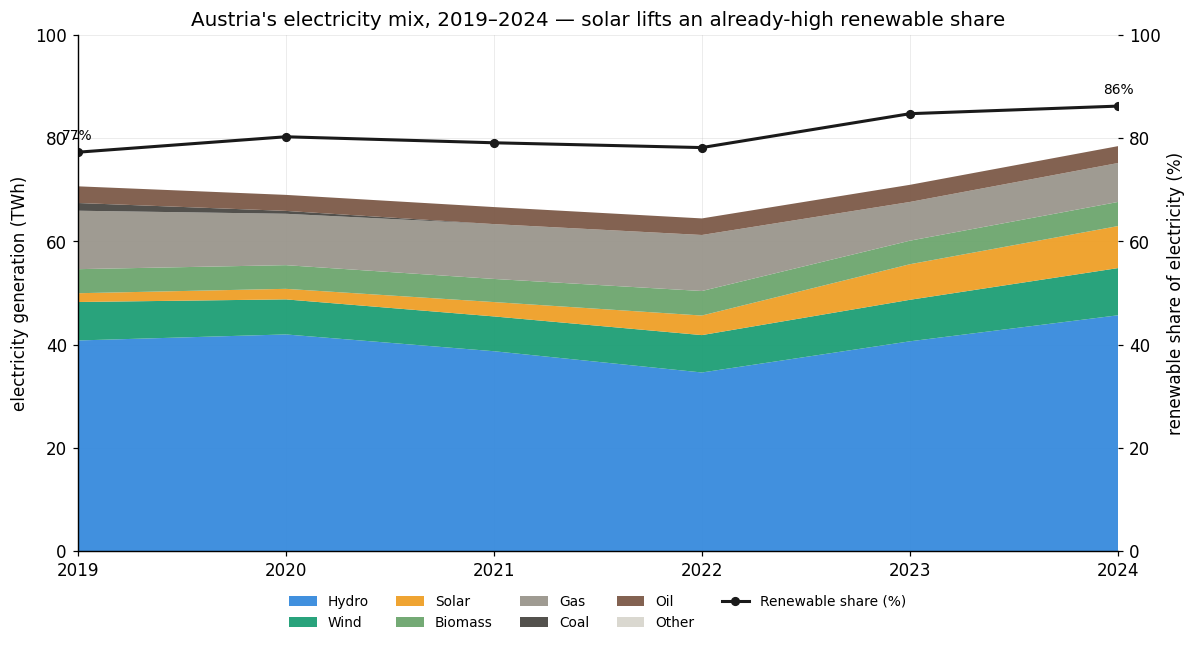

In [7]:
# Cell E: composition (TWh stack) + renewable share (%)
import sys

import matplotlib.pyplot as plt

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.viz import set_house_style, PALETTE
set_house_style()

# Source colours: renewables in the vivid house palette, fossils in greys/brown.
# That split is the rhetoric — the colourful block grows, the grey block shrinks.
# (The mix recurs in RQ3/RQ4 → Phase-5 candidate to lift into viz.py.)
MIX_COLORS = {
    "hydro":   PALETTE["hydro"],   "wind":  PALETTE["wind"],
    "solar":   PALETTE["solar"],   "biofuel": "#6CA66E",
    "gas":     "#9A968C",          "coal":  "#4A4843",
    "oil":     "#7C5A48",          "other": "#D8D6CE",
}
LABELS = {"hydro": "Hydro", "wind": "Wind", "solar": "Solar", "biofuel": "Biomass",
          "gas": "Gas", "coal": "Coal", "oil": "Oil", "other": "Other"}
order = ["hydro", "wind", "solar", "biofuel", "gas", "coal", "oil", "other"]  # bottom→top

mix = df_mix.set_index("year").copy()
mix["other"] = mix["other"].clip(lower=0)   # guard a tiny negative residual

fig, ax = plt.subplots(figsize=(11, 6))
ax.stackplot(mix.index, [mix[s] for s in order],
             labels=[LABELS[s] for s in order],
             colors=[MIX_COLORS[s] for s in order], alpha=0.95)
ax.set_ylabel("electricity generation (TWh)")
ax.set_ylim(0, 100)                 # headroom above the ~78 TWh peak
ax.set_xlim(mix.index.min(), mix.index.max())
ax.set_xticks(mix.index)
ax.set_title("Austria's electricity mix, 2019–2024 — solar lifts an already-high renewable share")

# Headline metric on a twin y-axis. twinx() shares the x-axis but gets its own y;
# both set 0–100 so the % line rides cleanly *above* the TWh stack every year
# (share% > total-gen-in-TWh for all six years) — no truncation, no overlap.
ax2 = ax.twinx()
ax2.plot(mix.index, mix["ren_share"], color="#1A1A1A", lw=2,
         marker="o", ms=5, label="Renewable share (%)")
ax2.set_ylabel("renewable share of electricity (%)")
ax2.set_ylim(0, 100)
ax2.grid(False)                     # left axis owns the gridlines
ax2.spines["top"].set_visible(False)

# Annotate endpoints → the +9 pp shift is explicit without truncating the axis.
for yr in (mix.index.min(), mix.index.max()):
    v = mix.loc[yr, "ren_share"]
    ax2.annotate(f"{v:.0f}%", (yr, v), textcoords="offset points",
                 xytext=(0, 8), ha="center", fontsize=9, fontweight="medium")

# One merged legend, below the axes (clears both the stack and the line).
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper center", bbox_to_anchor=(0.5, -0.06),
          ncol=5, fontsize=9)

plt.tight_layout()
plt.show()

**Finding (RQ1).** Austria's renewable share of electricity rose from **77% to 86%**
between 2019 and 2024, driven almost entirely by **solar's ~5× growth (1.7 → 8.1 TWh)**
and falling fossil output — not a broad-based shift. **Hydro stayed dominant throughout
(35–46 TWh)** and supplied most of the year-to-year volatility, so the headline share
moved less from "going green" than from incremental solar gains on top of an
already-renewable, hydro-based system.